## 3. Randomized Test Generation from Question Bank

A teacher maintains a question bank containing 100 questions labeled Q1 to Q100. For each unit test, 5 questions are selected at random from the bank.

### Tasks 1 & 2: Simulation Setup
1.  **Simulate Question Selection**:
    * (a) Write a function to randomly select 5 questions **with replacement** from the bank.
    * (b) Write a function to randomly select 5 questions **without replacement**.
2.  **Run Simulations**:
    * (a) Generate 10,000 simulated tests (each with 5 questions).
    * (b) Count how many times each question is selected in both modes.

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Create question bank (Q1 to Q100)
questions = np.arange(1, 101)
n_simulations = 10000
test_size = 5

# 1(a) & 2: With Replacement
# We can simulate all tests at once using numpy for efficiency
tests_with_replacement = np.random.choice(questions, size=(n_simulations, test_size), replace=True)

# 1(b) & 2: Without Replacement
# For 'without replacement', we need to loop or use specific numpy tricks 
# (sampling row-wise without replacement is tricky in one shot with standard choice, 
# but we can use argsort or loops. Loops are clearer for this lab context).
tests_without_replacement = np.array([np.random.choice(questions, size=test_size, replace=False) for _ in range(n_simulations)])

print(f"Generated {n_simulations} tests with replacement.")
print(f"Generated {n_simulations} tests without replacement.")

# Count frequencies (Task 2b)
unique_wr, counts_wr = np.unique(tests_with_replacement, return_counts=True)
unique_wo, counts_wo = np.unique(tests_without_replacement, return_counts=True)

# Simple check to see counts for first few questions
print("Frequency of Q1-Q5 (With Replacement):", counts_wr[:5])
print("Frequency of Q1-Q5 (Without Replacement):", counts_wo[:5])

Generated 10000 tests with replacement.
Generated 10000 tests without replacement.
Frequency of Q1-Q5 (With Replacement): [502 517 485 521 516]
Frequency of Q1-Q5 (Without Replacement): [479 500 479 491 518]


### Task 3: Compute Expected Unique Questions

1.  **With Replacement:** Compute the average number of unique questions in each test across simulations. Compare with the theoretical result.
    * Theoretical Formula for expected unique items ($E[U]$) when choosing $k$ items from $N$ with replacement:
        $$E[U] = N \left[ 1 - \left( 1 - \frac{1}{N} \right)^k \right]$$
2.  **Without Replacement:** Verify that the number of unique questions is always 5.

In [42]:
# Part A: With Replacement
unique_counts_wr = [len(np.unique(test)) for test in tests_with_replacement]
avg_unique_wr = np.mean(unique_counts_wr)

# Theoretical Calculation
N = 100
k = 5
theoretical_unique = N * (1 - (1 - 1/N)**k)

print(f"Average unique questions (With Replacement): {avg_unique_wr:.4f}")
print(f"Theoretical expectation: {theoretical_unique:.4f}")

# Part B: Without Replacement
unique_counts_wo = [len(np.unique(test)) for test in tests_without_replacement]
avg_unique_wo = np.mean(unique_counts_wo)

print(f"Average unique questions (Without Replacement): {avg_unique_wo}")

Average unique questions (With Replacement): 4.9061
Theoretical expectation: 4.9010
Average unique questions (Without Replacement): 5.0


### Task 4: Simulate Conditional Probability

Given **Q1** is selected, what is the chance **Q2** is also selected? Compare the theoretical and simulated results.

**Theoretical Formula (Without Replacement):**
$$P(Q2 | Q1) = \frac{k-1}{N-1}$$
(Since Q1 is taken, 4 spots remain out of 99 questions).

In [43]:
# We will analyze the "Without Replacement" dataset for this task
q1 = 1
q2 = 2

# Count tests containing Q1
tests_with_q1 = np.sum(np.any(tests_without_replacement == q1, axis=1))

# Count tests containing BOTH Q1 and Q2
# We verify if q1 is present AND q2 is present in the same row
has_q1 = np.any(tests_without_replacement == q1, axis=1)
has_q2 = np.any(tests_without_replacement == q2, axis=1)
tests_with_q1_and_q2 = np.sum(has_q1 & has_q2)

# Empirical Probability
prob_q2_given_q1 = tests_with_q1_and_q2 / tests_with_q1

# Theoretical Probability (Without Replacement)
# If Q1 is picked, 4 spots left. Pool has 99 items left. Chance Q2 is in those 4 spots = 4/99.
theoretical_prob = (test_size - 1) / (len(questions) - 1)

print(f"Simulated P(Q2 | Q1): {prob_q2_given_q1:.4f}")
print(f"Theoretical P(Q2 | Q1): {theoretical_prob:.4f}")

Simulated P(Q2 | Q1): 0.0585
Theoretical P(Q2 | Q1): 0.0404


### Task 5: Easy/Hard Questions (Bayes' Theorem)

Assume 30 questions are randomly labeled as **Easy** and 70 as **Hard**.
During a test, one question is selected (with replacement) and a student answers it.
* If **Easy**, student answers correctly with probability $P(Correct|Easy) = 0.9$.
* If **Hard**, student answers correctly with probability $P(Correct|Hard) = 0.4$.

**Goal:** Given the student answered correctly, estimate the probability the question was Easy: $P(Easy | Correct)$.

**Theoretical Formula (Bayes' Theorem):**
$$P(E|C) = \frac{P(C|E)P(E)}{P(C)} = \frac{P(C|E)P(E)}{P(C|E)P(E) + P(C|H)P(H)}$$

In [44]:
# Setup
n_trials = 10000
p_easy = 0.3
p_hard = 0.7
prob_correct_given_easy = 0.9
prob_correct_given_hard = 0.4

# Simulation
# 1. Randomly choose difficulty (Easy=1, Hard=0) based on priors
is_easy = np.random.rand(n_trials) < p_easy

# 2. Determine if answered correctly
# Generate random numbers for success check
random_vals = np.random.rand(n_trials)

# Vectorized check:
# If Easy (True), success if rand < 0.9. If Hard (False), success if rand < 0.4.
is_correct = np.where(is_easy, random_vals < prob_correct_given_easy, random_vals < prob_correct_given_hard)
print(is_correct[:10])
# 3. Filter for correct answers
correct_indices = np.where(is_correct)[0]
print(correct_indices[:5])
total_correct = len(correct_indices)
correct_and_easy = np.sum(is_easy[correct_indices])

# Empirical Probability
prob_easy_given_correct_sim = correct_and_easy / total_correct

# Theoretical Probability
prob_correct = (prob_correct_given_easy * p_easy) + (prob_correct_given_hard * p_hard)
prob_easy_given_correct_theory = (prob_correct_given_easy * p_easy) / prob_correct

print(f"Simulated P(Easy | Correct): {prob_easy_given_correct_sim:.4f}")
print(f"Theoretical P(Easy | Correct): {prob_easy_given_correct_theory:.4f}")

[ True False  True False  True False False False  True False]
[ 0  2  4  8 12]
Simulated P(Easy | Correct): 0.4988
Theoretical P(Easy | Correct): 0.4909


### Task 6: Box Plot

Group 1,000 tests and record the average number of distinct questions. Repeat this for 10 such groups. [cite_start]Create a boxplot with 10 boxes, where each box shows the average number of distinct questions[cite: 290, 291].

*(Note: The prompt is slightly ambiguous on "boxplot with 10 boxes" vs "1 box from 10 data points". Usually, one boxplot summarizes the distribution of the 10 group means, or we simulate 10 separate batches. Here, we will generate 10 groups of 1,000 tests and boxplot the distribution of "unique counts" for each group to compare stability).*

/tmp/ipykernel_1891394/3335708152.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(group_data, labels=[f"Grp {i+1}" for i in range(groups)])


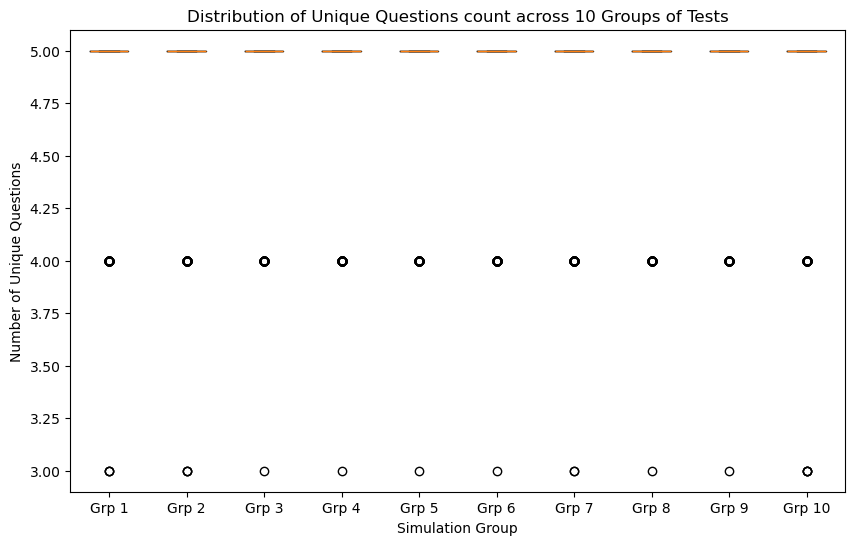

In [45]:

groups = 10
tests_per_group = 1000
group_data = []

plt.figure(figsize=(10, 6))

for i in range(groups):
    # Generate batch
    batch_tests = np.random.choice(questions, size=(tests_per_group, test_size), replace=True)
    # Count unique in each test of this batch
    batch_unique_counts = [len(np.unique(t)) for t in batch_tests]
    group_data.append(batch_unique_counts)

# Plotting
plt.boxplot(group_data, labels=[f"Grp {i+1}" for i in range(groups)])
plt.title("Distribution of Unique Questions count across 10 Groups of Tests")
plt.ylabel("Number of Unique Questions")
plt.xlabel("Simulation Group")
plt.show()

### Task 7: Heatmap

In 10,000 tests (5 questions each), count how often each pair of questions is selected together. Plot a $100 \times 100$ heatmap of co-selection frequencies.

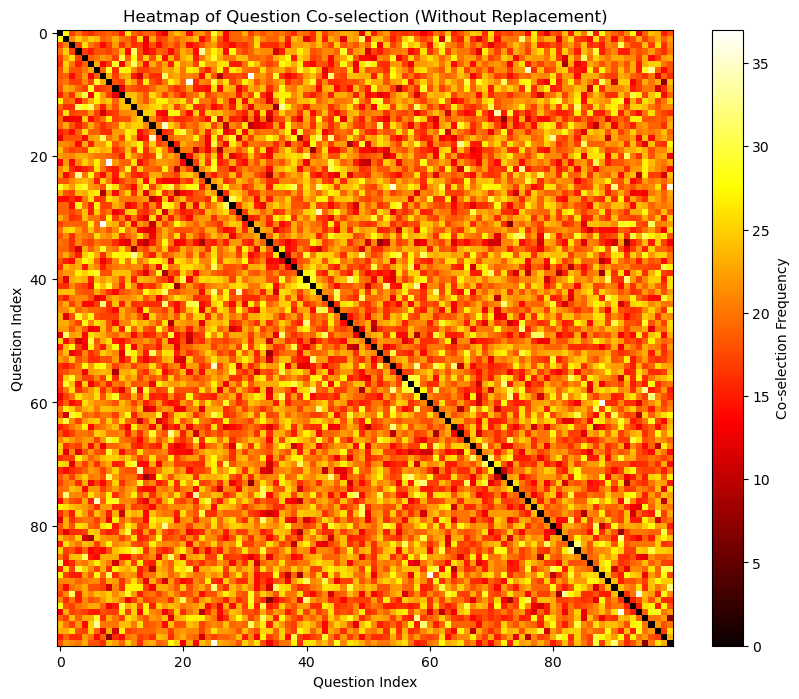

In [46]:
import itertools

# Initialize 100x100 matrix
co_occurrence_matrix = np.zeros((100, 100))

# Iterate through the "without replacement" tests from earlier
for test in tests_without_replacement:
    # Generate all pairs in this test
    # test contains question IDs 1-100, we need indices 0-99
    indices = test - 1 
    for i, j in itertools.combinations(indices, 2):
        co_occurrence_matrix[i, j] += 1
        co_occurrence_matrix[j, i] += 1 # Symmetric

plt.figure(figsize=(10, 8))
plt.imshow(co_occurrence_matrix, cmap='hot', interpolation='nearest')
plt.colorbar(label='Co-selection Frequency')
plt.title("Heatmap of Question Co-selection (Without Replacement)")
plt.xlabel("Question Index")
plt.ylabel("Question Index")
plt.show()

### Task 8: Biased Sampling

1.  **Modify Selection:** Questions Q1 to Q20 are more likely to be selected.
2.  **Visualization:** Plot the frequency histogram and note the impact of bias.

*Implementation Note: We assign a higher weight to Q1-Q20 and lower to Q21-Q100, then normalize to create valid probabilities.*

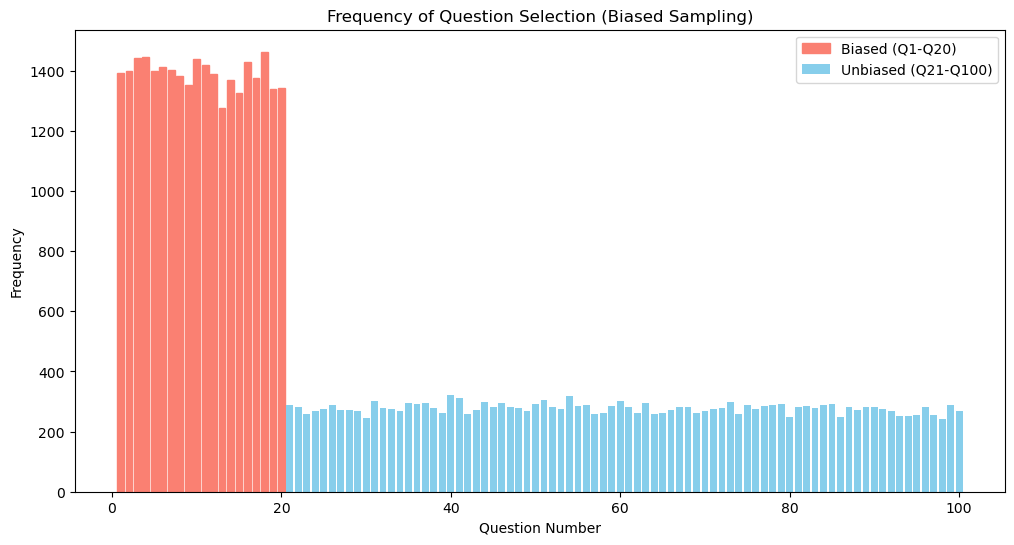

In [47]:
# Weights
weights = np.ones(100)
weights[:20] = 5  # First 20 questions are 5x more likely
weights[20:] = 1  # Remaining are standard

# Normalize to sum to 1
prob_dist = weights / np.sum(weights)

# Simulate
biased_tests = np.random.choice(questions, size=(10000, test_size), replace=True, p=prob_dist)

# Count frequencies
unique, counts = np.unique(biased_tests, return_counts=True)

# Fill in 0 for questions that might not have been picked (unlikely with 10k tests but good practice)
freq_map = dict(zip(unique, counts))
all_counts = [freq_map.get(q, 0) for q in questions]

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(questions, all_counts, color='skyblue')

# Highlight the biased items
for i in range(20):
    bars[i].set_color('salmon')

plt.title("Frequency of Question Selection (Biased Sampling)")
plt.xlabel("Question Number")
plt.ylabel("Frequency")
plt.legend([bars[0], bars[20]], ['Biased (Q1-Q20)', 'Unbiased (Q21-Q100)'])
plt.show()